# Figure workshop

Design the figures here, with the plotting code inline so it can be edited
directly. Once a figure settles, its code moves into
`scripts/make_figures.py` so every figure can be regenerated with one command
after a rerun.

Until that port happens the script holds an older draft of these figures, so
the notebook is the working copy and the script is stale. Do not edit both.

Each figure cell builds a `fig` and stashes it in `FIGS` via `keep()`. The
inline backend renders it automatically, so the cells deliberately end without
returning anything. The save cell near the bottom writes everything in `FIGS`
to `figures/` as PNG and PDF, so nothing reaches disk until you decide it is
ready.

Re-run the setup cell after editing it, since `keep` is defined there.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from constellaration_uq.data import filter_valid, load_raw
from constellaration_uq.results import REPO_ROOT, load_results
from constellaration_uq.splits import (
    hole_split,
    tail_split,
)

DATA_DIR = REPO_ROOT / 'data_raw' / 'data'
FIGURES_DIR = REPO_ROOT / 'figures'
AXIS = 'metrics.aspect_ratio'
TEST_FRACTION = 0.2

# Percentile 30, so the band runs 20 to 40. Chosen from scripts/hole_placement.py:
# it sits immediately above the tail's percentiles 0 to 20 without overlapping,
# so the hole-versus-edge contrast controls for local sparsity. Defined once here
# because several figures use it and a hardcoded default would drift between them.
HOLE_CENTRE = 0.30

FIGS = {}


def keep(fig, name):
    """Stash a figure for the save cell.

    Deliberately returns nothing. %matplotlib inline already renders every
    figure a cell creates, so returning it would make the cell's output value
    render it a second time and every figure would appear twice.
    """
    FIGS[name] = fig

## Style

Edit here rather than per figure. The same colour must mean the same thing
everywhere, which matters more than any individual choice.

In [2]:
COLOR_TRAIN = '#9ecae1'
COLOR_TAIL = '#d94801'
COLOR_HOLE = '#2171b5'
COLOR_NEUTRAL = '#525252'

plt.rcParams.update(
    {
        'figure.figsize': (8, 4.5),
        'figure.dpi': 110,
        'savefig.dpi': 150,
        'savefig.bbox': 'tight',
        'axes.grid': True,
        'grid.alpha': 0.25,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 10,
    }
)

## Load the axis

Slow cell, roughly 10 to 20 seconds, almost all of it reading parquet. Only the
aspect ratio column is needed, never the 80-coefficient flatten. Run once.

In [3]:
for _, _df in filter_valid(load_raw(DATA_DIR)):
    pass

axis = _df[AXIS].to_numpy()
print(f'{len(axis):,} rows, aspect ratio {axis.min():.2f} to {axis.max():.2f}')

27,050 rows, aspect ratio 3.92 to 12.11


## Figure 1: where the cuts fall

The explanatory figure. Shows the sampling density, where the tail cut lands,
and how narrow the hole is by comparison.

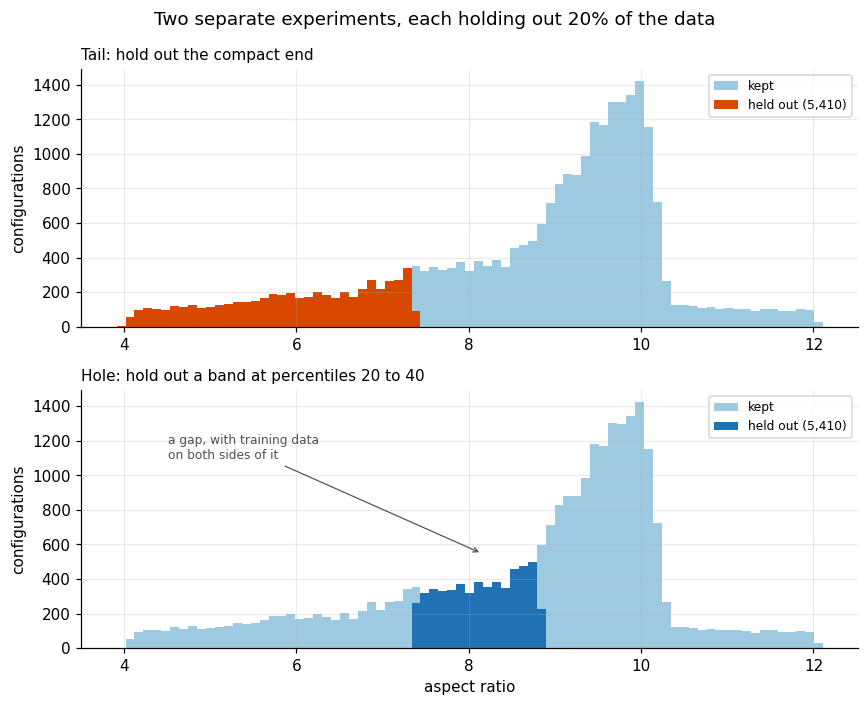

In [4]:
_, tail_test = tail_split(axis, 'low', TEST_FRACTION)
_, hole_test = hole_split(axis, TEST_FRACTION, HOLE_CENTRE)

fig, (ax_tail, ax_hole) = plt.subplots(2, 1, sharex=False, figsize=(8, 6.5))
bins = np.linspace(axis.min(), axis.max(), 80)

panels = [
    (ax_tail, tail_test, COLOR_TAIL, 'Tail: hold out the compact end'),
    (ax_hole, hole_test, COLOR_HOLE, 'Hole: hold out a band at percentiles 20 to 40'),
]

for ax, test_mask, color, title in panels:
    ax.hist(axis, bins=bins, color=COLOR_TRAIN, label='kept')
    ax.hist(axis[test_mask], bins=bins, color=color, label=f'held out ({test_mask.sum():,})')
    ax.set_ylabel('configurations')
    ax.set_title(title, fontsize=10, loc='left')
    ax.legend(fontsize=8)

# Tip height derived from the bars so it lands on them rather than above.
hole_counts, _ = np.histogram(axis[hole_test], bins=bins)

ax_hole.annotate(
    'a gap, with training data\non both sides of it',
    xy=(axis[hole_test].mean(), hole_counts.max() * 1.10),
    xytext=(axis.min() + 0.6, hole_counts.max() * 2.2),
    fontsize=8,
    color=COLOR_NEUTRAL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_NEUTRAL, 'lw': 0.8},
)


ax_hole.set_xlabel('aspect ratio')
fig.suptitle('Two separate experiments, each holding out 20% of the data')
fig.tight_layout()

keep(fig, 'split_design')

## Table 1: does the pipeline reproduce Appendix A.4?

Before any claim of our own. Proxima's Appendix A.4 trains an ensemble of ten
MLPs on these boundary coefficients and reports Table 7. If our loader, filters,
trimming, scaling and architecture are right, our numbers should land near
theirs. If they do not, nothing downstream can be trusted.

**The headline row is the first one**, our plain-MSE ensemble against theirs.
That is the like-for-like comparison: A.4 trained by minimising mean squared
error, so comparing a mean-variance ensemble's RMSE to it would compare two
different training objectives.

**The other two rows are the consistency check**, and they matter more than they
look. One untuned single MLP lands at 2.4x Table 7 on edge rotational transform
and 2.8x on log10 qi. **A pipeline bug would not produce a consistent factor
across two unrelated metrics**; it would break one and not the other, or break
both differently. Two similar ratios is positive evidence the plumbing is right.

⚠️ **RMSE only, never R².** Ours is 0.982 against their 0.997, which reads far
worse than the RMSE ratio implies, because R² depends on the test set's own
spread: 0.0789 for us against roughly 0.115 back-solved from their table. RMSE
is the comparable number and R² is not.

⚠️ **There is no log10 qi ensemble.** That row is a single untuned MLP from the
day 1-2 grid and is labelled as such. A second target is optional scope,
deliberately deferred, and quoting 2.8x as "our qi result" would be wrong.

⚠️ **Our pool is 27,050 against A.4's stated ~23k**, applying every filter their
published loader performs. Two intermediate counts land exactly on published
figures (158,685 evaluated without errors, 68,191 at NFP=3), so the chain is
right and their appendix is incomplete somewhere. Documented rather than forced.


In [5]:
mse = load_results('mse_ensemble')['results']
grid_rows = load_results('day_1_2_grid')['results']['rows']


def grid_in_region(target):
    """In-region RMSE for one target from the day 1-2 grid.

    Averaged over the three cuts of the winning axis. Each is a separate fit of
    the same untuned single MLP, and they differ only in which rows were held
    out, so their in-region numbers are three samples of one quantity.
    """
    matching = [
        r['rmse_in'] for r in grid_rows if r['target'] == target and r['axis'] == 'aspect_ratio'
    ]
    return float(np.mean(matching))


# Table 7 values, transcribed from the paper. Stored in the results file for the
# primary target; the qi figure has no run of ours to sit beside it.
TABLE_7 = {
    'edge_rotational_transform_over_n_field_periods': mse['table_7_rmse'],
    'log_10_qi': 0.051,
}

comparison = pd.DataFrame(
    [
        {
            'metric': 'edge rotational transform',
            'model': 'ours: 10-member MSE ensemble',
            'table_7_rmse': TABLE_7['edge_rotational_transform_over_n_field_periods'],
            'our_rmse': mse['ensemble_rmse'],
        },
        {
            'metric': 'edge rotational transform',
            'model': 'ours: one untuned MLP',
            'table_7_rmse': TABLE_7['edge_rotational_transform_over_n_field_periods'],
            'our_rmse': grid_in_region('edge_rot_transform'),
        },
        {
            'metric': 'log10 qi',
            'model': 'ours: one untuned MLP (no ensemble run)',
            'table_7_rmse': TABLE_7['log_10_qi'],
            'our_rmse': grid_in_region('log10_qi'),
        },
    ]
)
comparison['ratio'] = comparison['our_rmse'] / comparison['table_7_rmse']
comparison.round({'table_7_rmse': 4, 'our_rmse': 5, 'ratio': 2})

,metric,model,table_7_rmse,our_rmse,ratio
0,edge rotational transform,ours: 10-member MSE ensemble,0.006,0.01052,1.75
1,edge rotational transform,ours: one untuned MLP,0.006,0.01458,2.43
2,log10 qi,ours: one untuned MLP (no ensemble run),0.051,0.14489,2.84


## Table 2: the decomposition, and where calibration breaks

The project's headline. Three splits, each training its own ten-member
mean-variance ensemble on the same architecture and recipe, evaluated on two
held-out sets: a slice carved from inside the training region, and the split's
own out-of-region set.

**Read the `ratio` column.** It is predicted uncertainty divided by the error it
is predicting. 1.0 is honest, above 1.0 is cautious, below 1.0 is overconfident.

In region it runs 1.04 to 1.18 on all three splits, so the model is slightly
cautious, which is the safe direction. Out of region it falls to 0.69 for the
hole and 0.66 for the tail. **The random split is the control** and stays near
its in-region value, which is what makes the other two readable as shift rather
than as an artifact of the diagnostic.

`cov@0.9` is the same failure in the form a deferral threshold can use: the
stated 90% interval holds 0.95 to 0.97 of the truth in region and 0.779 at the
tail. `pit_mean` separates two faults that coverage cannot: below 0.5 means the
prediction itself is drifting, not merely that the interval is too narrow.

⚠️ **Single seed.** Every number here is seed 0, as is every coverage, PIT, CRPS
and deferral figure in this project. Only the N-sweep has replication, and its
three seeds put per-rung spreads near ±1% on epistemic. The differences this
table rests on are far larger than that, but no spread has been measured for
them and none should be implied.

⚠️ **The tail's out-of-region set is conservative by about 2%.** The 0.05%
target trim reads held-out labels, and 22 of the 28 rows it removes fall inside
this split's held-out region. Restoring the ordinary ones moves the ratio from
3.24x to 3.31x. Measured, not assumed: see decision log 1.4.


In [6]:
calibration = load_results('calibration')['results']

LABELS = {'random': 'random', 'hole': 'hole p30', 'tail': 'tail-low'}

decomposition = pd.DataFrame(
    [
        {
            'split': LABELS[name],
            'region': region.replace('-region', '').replace('-of', ''),
            'n': sets[region]['n'],
            'rmse': sets[region]['rmse'],
            'epistemic': sets[region]['epistemic'],
            'aleatoric': sets[region]['aleatoric'],
            'total': sets[region]['total'],
            'ratio': sets[region]['total_over_rmse'],
            'cov@0.9': sets[region]['coverage_0.9'],
            'pit_mean': sets[region]['pit_mean'],
        }
        for name in ('random', 'hole', 'tail')
        for sets in [calibration[name]['sets']]
        for region in ('in-region', 'out-of-region')
    ]
)
decomposition.round(
    {'rmse': 5, 'epistemic': 5, 'aleatoric': 5, 'total': 5, 'ratio': 2, 'cov@0.9': 3, 'pit_mean': 3}
)

,split,region,n,rmse,epistemic,aleatoric,total,ratio,cov@0.9,pit_mean
0,random,in,4324,0.01256,0.00887,0.01194,0.01487,1.18,0.966,0.518
1,random,out,5404,0.01280,0.00895,0.01161,0.01466,1.15,0.962,0.514
2,hole p30,in,4324,0.01252,0.00813,0.01010,0.01297,1.04,0.950,0.506
3,hole p30,out,5404,0.02484,0.01197,0.01209,0.01702,0.69,0.871,0.531
4,tail-low,in,4324,0.01223,0.00834,0.01032,0.01327,1.09,0.956,0.507
5,tail-low,out,5405,0.03962,0.01457,0.02189,0.02630,0.66,0.779,0.348


## Hole placement: a decision, not a figure

The placement sweep asked one question, where to centre the interior hole, and
answered it: percentile 30, which sits immediately above the tail's percentiles
0 to 20 without overlapping them. That makes it a design-decision record, so it
is a table.

Two earlier attempts to plot it are gone. Both drew eight independent
experiments as points on a single axis, and both were misread, because nothing
in that picture tells a reader that each point is its own model fit rather than
a sample from one curve.

`results/hole_placement.json` is the 20% sweep, centres p20 to p80.
`results/hole_placement_narrow.json` is a 10% sweep, centres p10 to p90, and it
is the only run that reaches the sparse upper end. The narrow run shows the
penalty is a U in placement, lowest in the dense middle and rising at both ends,
which means gap width rather than proximity to the compact edge drives most of
it. Treat that as suggestive: its two load-bearing rows carry about 130 points
in their thinnest distance bin against roughly 310 elsewhere, at a single seed.


In [7]:
sweep = load_results('hole_placement')['results']['rows']

pd.DataFrame(sweep)[
    [
        'split',
        'percentiles',
        'n_held_out',
        'rmse_in',
        'rmse_out',
        'ratio',
        'reach',
        'min_bin',
        'delta',
    ]
].round({'rmse_in': 5, 'rmse_out': 5, 'ratio': 2, 'reach': 2, 'delta': 3})

,split,percentiles,n_held_out,rmse_in,rmse_out,ratio,reach,min_bin,delta
0,tail-low,0 to 20,5405,0.01379,0.04157,3.02,2.13,276,0.059
1,hole,10 to 30,5404,0.01417,0.02777,1.96,0.63,602,0.040
2,hole,20 to 40,5404,0.01452,0.02615,1.80,0.45,583,0.041
3,hole,30 to 50,5404,0.01479,0.01658,1.12,0.31,586,0.040
4,hole,40 to 60,5404,0.01476,0.01406,0.95,0.20,641,0.039
5,hole,50 to 70,5404,0.01526,0.01377,0.90,0.16,616,0.039
6,hole,60 to 80,5404,0.01552,0.01240,0.80,0.14,645,0.039
7,hole,70 to 90,5404,0.01567,0.01283,0.82,0.13,602,0.040


## Figure 2: error against distance from the training data

Deliverable one, in single-model form. Every point on these curves is a bin of
roughly 675 held-out configurations rather than a whole experiment, which is
what makes it readable in a way the placement sweep never was.

Three splits, one MLP each, same recipe as the day 1-2 grid. Each curve starts
at that split's own in-region error, measured on a held-out slice carved from
the training region, then follows the binned error outward.

**The finding.** At matched distance the tail sits above the hole by about 12%
over the whole shared range (0.02929 against 0.02615). So most of the headline
gap, 3.02 against 1.80, is distance rather than edge: the tail split simply asks
about configurations much further from the data. What survives after distance is
controlled for is the edge cost itself, and it is real but modest.

⚠️ Measured in identical fixed-width windows by `distance_error.matched_windows`
and saved to `results/distance_error_matched.csv`. An earlier version of this
cell read "roughly 15% at both 0.2 and 0.4 std out", derived by reading the two
binned curves at their bin medians. The bins are equal-count, so their widths
differ where the splits differ in density, and a wide bin's RMSE is dominated by
its far edge. Do not read a trend across the windows either: four of the five
sit between 1.03 and 1.13 with no ordering.

The shaded band is the only range where both splits have points, so it is the
only range where that comparison exists at all. Past 0.45 the tail continues
alone, and nothing can be said about how a gap would behave out there.

That band also replaces what used to be a separate reach histogram. It made the
same point, was repeatedly misread, and the two numbers it carried now live in
the placement table's `reach` column and in the band's own annotation.

Reads `results/distance_error.json`. Per-point rows are in
`results/distance_error_points.csv` if the bins ever need redrawing.


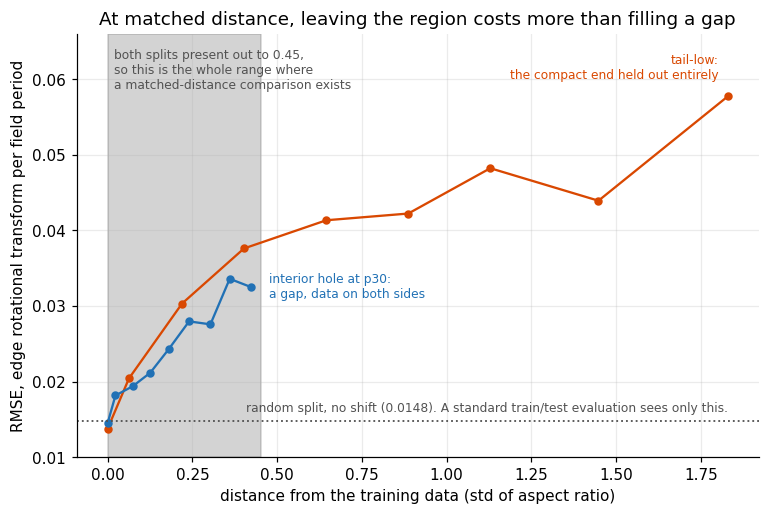

In [8]:
splits = load_results('distance_error')['results']['splits']

# Direct labels instead of a legend. Two series only, and the legend box was
# landing on the baseline label in the one corner both wanted.
SERIES = {
    'tail_low': (
        'tail-low:\nthe compact end held out entirely',
        COLOR_TAIL,
        {'xytext': (-6, 12), 'ha': 'right'},
    ),
    'hole_p30': (
        'interior hole at p30:\na gap, data on both sides',
        COLOR_HOLE,
        {'xytext': (12, 0), 'ha': 'left', 'va': 'center'},
    ),
}

fig, ax = plt.subplots(figsize=(8, 5))

# Pinned so the annotations below have somewhere reliable to sit.
ax.set_ylim(0.010, 0.066)

for name, (label, color, placement) in SERIES.items():
    split = splits[name]
    # Each curve starts from its own in-region error at distance zero rather
    # than from a shared baseline. The two differ by about 5%, and drawing one
    # line for both would hide that.
    d = [0.0, *[b['d_median'] for b in split['bins']]]
    err = [split['in_region']['rmse'], *[b['rmse'] for b in split['bins']]]
    ax.plot(d, err, 'o-', color=color, markersize=4.5)
    ax.annotate(
        label,
        (d[-1], err[-1]),
        textcoords='offset points',
        fontsize=8,
        color=color,
        **placement,
    )

# The random split is a reference level, not a series. Its held-out points never
# get more than 0.01 from training data, so drawn as a curve it is eight dots on
# the y axis that read as noise on the other two. As a line it does the job it is
# actually for: making the vertical gap to the no-shift baseline readable at
# every distance.
random = splits['random']
far = splits['tail_low']['bins'][-1]['d_median']
ax.axhline(random['rmse_out'], color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax.annotate(
    f'random split, no shift ({random["rmse_out"]:.4f}). '
    'A standard train/test evaluation sees only this.',
    (far, random['rmse_out']),
    textcoords='offset points',
    xytext=(0, 6),
    ha='right',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

# The hole cannot reach past here, so neither can the comparison. Sits inside
# the band, top left, where both curves are still low.
overlap = splits['hole_p30']['reach']
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)
ax.annotate(
    f'both splits present out to {overlap:.2f},\nso this is the whole range where\n'
    'a matched-distance comparison exists',
    (0.02, 0.064),
    va='top',
    ha='left',
    fontsize=8,
    color=COLOR_NEUTRAL,
)

ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('RMSE, edge rotational transform per field period')
ax.set_title('At matched distance, leaving the region costs more than filling a gap')

keep(fig, 'distance_error')

## Load the uncertainty results

Everything below reads `results/*.json` and `results/*.csv` written by
`scripts/calibration.py`, `scripts/deferral.py` and `scripts/n_sweep.py`. No
training, no parquet, under a second.


In [9]:
cal = load_results('calibration')
calibration = cal['results']
LEVELS = cal['constants']['LEVELS']

deferral = load_results('deferral')['results']
deferral_curve = pd.read_csv(REPO_ROOT / 'results' / 'deferral_curve.csv')

sweep = load_results('n_sweep')
sweep_cells = sweep['results']['cells']
sweep_avg = sweep['results']['averaged']

# ⚠️ pts.split would call DataFrame.split, not the column. Always bracket it.
pit_points = pd.read_csv(REPO_ROOT / 'results' / 'calibration_points.csv')

print('splits:', list(calibration))
print('nominal levels:', LEVELS)
print('sweep cells:', len(sweep_cells), 'complete:', sweep['results']['complete'])

splits: ['random', 'hole', 'tail']
nominal levels: [0.5, 0.68, 0.8, 0.9, 0.95, 0.99]
sweep cells: 30 complete: True


## Figure 3: the stated interval stops being the stated interval

Deliverable one in its actionable form, and the figure a deferral threshold
rests on. Same x axis as Figure 2, by construction: both use
`metrics.distance_bins`, so the two can be read side by side and the second
answers what the first leaves open.

Figure 2 says the error grows with distance. That alone is not a problem, since
a model that reports larger error bars as it gets worse is behaving correctly.
This asks whether it does. The y axis is the fraction of truths that actually
landed inside the model's own 90% interval, so an honest model tracks the
dotted line at every distance.

**The finding.** It does not. In region the interval holds 95 to 97%, slightly
conservative. Past the compact edge it falls to 59%, so a stated 90% interval
is closer to a 60% interval out there. The hole degrades too but shallower, and
it flattens rather than continuing down.


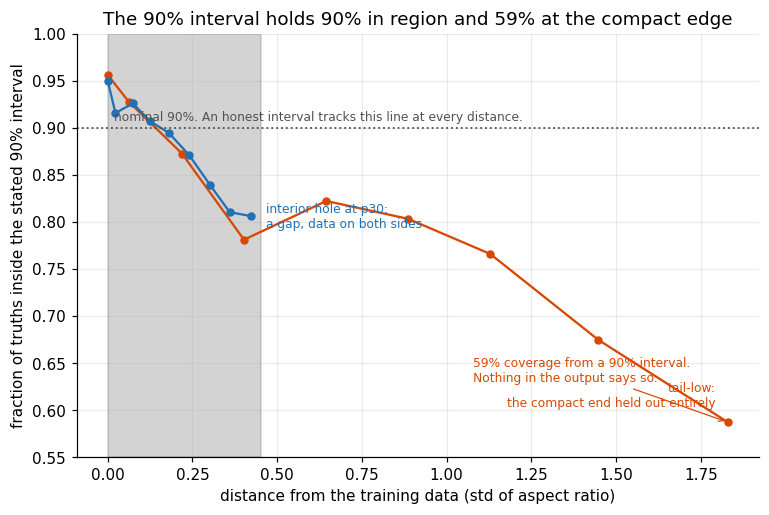

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

SERIES = {
    'tail': (
        'tail-low:\nthe compact end held out entirely',
        COLOR_TAIL,
        {'xytext': (-8, 10), 'ha': 'right'},
    ),
    'hole': (
        'interior hole at p30:\na gap, data on both sides',
        COLOR_HOLE,
        {'xytext': (10, 0), 'ha': 'left', 'va': 'center'},
    ),
}

for name, (label, color, placement) in SERIES.items():
    split = calibration[name]
    # In-region is one anchor at distance zero, not the first bin, matching the
    # convention in Figure 2 and in scripts/calibration.py.
    d = [0.0, *[b['d_median'] for b in split['bins']]]
    cov = [
        split['sets']['in-region']['coverage_0.9'],
        *[b['coverage_0.9'] for b in split['bins']],
    ]
    ax.plot(d, cov, 'o-', color=color, markersize=4.5)
    ax.annotate(
        label,
        (d[-1], cov[-1]),
        textcoords='offset points',
        fontsize=8,
        color=color,
        **placement,
    )

ax.axhline(0.9, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax.annotate(
    'nominal 90%. An honest interval tracks this line at every distance.',
    (0.02, 0.905),
    fontsize=8,
    color=COLOR_NEUTRAL,
    va='bottom',
)

overlap = max(b['d_hi'] for b in calibration['hole']['bins'])
ax.axvspan(0, overlap, color=COLOR_NEUTRAL, alpha=0.25)

worst = calibration['tail']['bins'][-1]
ax.annotate(
    f'{worst["coverage_0.9"]:.0%} coverage from a 90% interval.\nNothing in the output says so.',
    xy=(worst['d_median'], worst['coverage_0.9']),
    xytext=(worst['d_median'] - 0.75, 0.63),
    fontsize=8,
    color=COLOR_TAIL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)

ax.set_ylim(0.55, 1.0)
ax.set_xlabel('distance from the training data (std of aspect ratio)')
ax.set_ylabel('fraction of truths inside the stated 90% interval')
ax.set_title('The 90% interval holds 90% in region and 59% at the compact edge')

keep(fig, 'coverage_distance')

## Figure 4: calibration at every confidence level

Figure 4 fixes the confidence level at 90% and varies distance. This does the
opposite: it sweeps the level and separates in-region from out-of-region, so a
reader can check the failure is not an artifact of one arbitrary choice.

The diagonal is perfect calibration. Above it the model is conservative, below
it overconfident. Random is the control and should sit on the diagonal in both
regions, which is what makes the other two panels readable as shift rather than
as a quirk of the diagnostic.


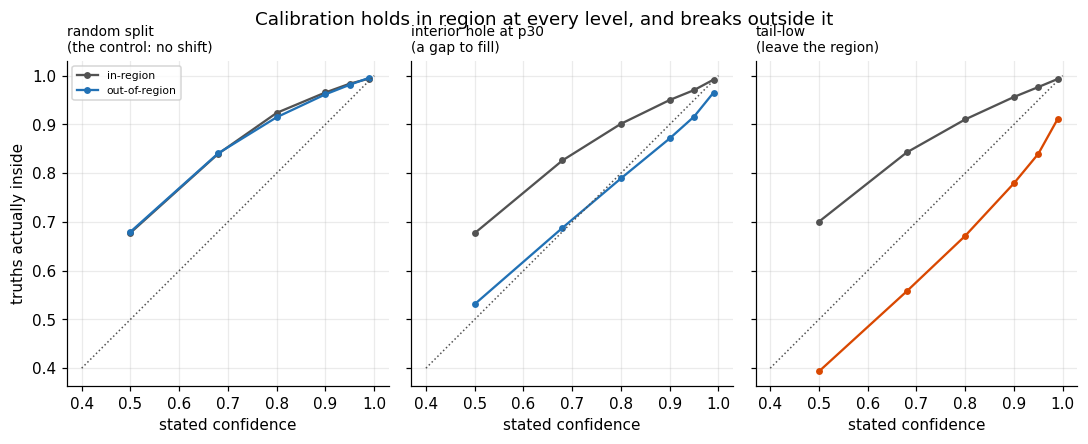

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), sharex=True, sharey=True)

TITLES = {
    'random': 'random split\n(the control: no shift)',
    'hole': 'interior hole at p30\n(a gap to fill)',
    'tail': 'tail-low\n(leave the region)',
}

for ax, (name, title) in zip(axes, TITLES.items(), strict=True):
    for region, color, style in (
        ('in-region', COLOR_NEUTRAL, '-'),
        ('out-of-region', COLOR_TAIL if name == 'tail' else COLOR_HOLE, '-'),
    ):
        measured = [calibration[name]['sets'][region]['coverage'][f'{lv:g}'] for lv in LEVELS]
        ax.plot(LEVELS, measured, style, marker='o', markersize=3.5, color=color, label=region)

    ax.plot([0.4, 1.0], [0.4, 1.0], ':', color=COLOR_NEUTRAL, linewidth=1)
    ax.set_title(title, fontsize=9, loc='left')
    ax.set_xlabel('stated confidence')
    ax.set_aspect('equal')

axes[0].set_ylabel('truths actually inside')
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Calibration holds in region at every level, and breaks outside it')
fig.tight_layout()

keep(fig, 'coverage_nominal')

## Figure 5: what kind of wrong

Coverage says how badly the intervals are calibrated. It cannot say which way,
and two very different faults produce the same coverage number: intervals too
narrow but centred correctly, or intervals fine but the prediction itself
biased. They need different fixes, so the distinction is worth a figure.

PIT is where each truth landed inside its own predicted distribution, on a 0 to
1 scale. A calibrated model spreads them evenly, so the bars sit on the dotted
line. Piling up at both ends means intervals too narrow. **Leaning to one side
means the mean is biased**, and widening the error bars would not help.

**The finding, and it is the one coverage missed.** The tail's out-of-region
panel leans hard left, mean PIT 0.348 against 0.51 everywhere else. The truth
keeps landing below the prediction, so the model systematically over-predicts
edge rotational transform at the compact edge. The hole shows nothing like it,
which separates the two conditions a second time.

Aggregate only, per decision log 7.1. Binned by distance these bars would rest
on about 60 points each and jump around from sampling noise alone.


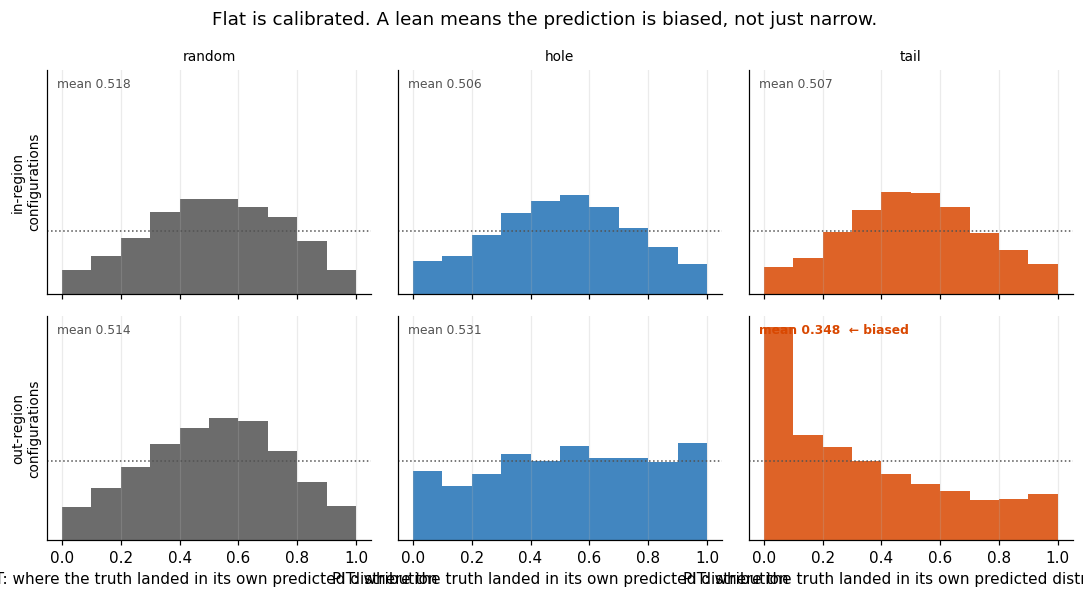

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.5), sharex=True, sharey=True)

COLUMNS = ['random', 'hole', 'tail']
bins = np.linspace(0, 1, 11)

for col, name in enumerate(COLUMNS):
    for row, region in enumerate(['in', 'out']):
        ax = axes[row, col]
        sel = pit_points[(pit_points['split'] == name) & (pit_points['region'] == region)]
        color = COLOR_TAIL if name == 'tail' else COLOR_HOLE
        if name == 'random':
            color = COLOR_NEUTRAL

        ax.hist(sel['pit'], bins=bins, color=color, alpha=0.85)
        ax.axhline(len(sel) / 10, color=COLOR_NEUTRAL, linestyle=':', linewidth=1)

        mean_pit = sel['pit'].mean()
        biased = abs(mean_pit - 0.5) > 0.05
        ax.annotate(
            f'mean {mean_pit:.3f}' + ('  ← biased' if biased else ''),
            (0.03, 0.92),
            xycoords='axes fraction',
            fontsize=8,
            color=COLOR_TAIL if biased else COLOR_NEUTRAL,
            fontweight='bold' if biased else 'normal',
        )
        if row == 0:
            ax.set_title(name, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{region}-region\nconfigurations', fontsize=9)
        ax.set_yticks([])

for ax in axes[1]:
    ax.set_xlabel('PIT: where the truth landed in its own predicted distribution')

fig.suptitle('Flat is calibrated. A lean means the prediction is biased, not just narrow.')
fig.tight_layout()

keep(fig, 'pit_histograms')

## Figure 6: the deferral curve

Deliverable two, and the answer to the obvious objection to Figures 4 to 6. If
the intervals cannot be trusted as intervals off-distribution, is the
uncertainty worth anything at all?

Yes, because deferral does not need the interval. It needs the **ordering**.
Rank the held-out shapes by predicted uncertainty, send the worst fraction to
VMEC++, keep the surrogate's answer for the rest. The y axis scores the whole
hybrid system, with deferred points credited exact.

**The finding.** Solving the worst 20% by uncertainty cuts CRPS by 41%, against
20% for a random 20%. Halving the error takes 27% of designs solved rather than
50%. The signal captures 63% of the headroom between the random floor and a
perfect ranking.

**The pairing with Figures 4 to 6 is the honest summary of the project:** the
intervals are badly miscalibrated at the compact edge, and the ranking still
works there. A signal can be useless as an absolute interval and good at
ordering.

⚠️ Deferred points are credited the exact solver value, so this assumes the
solver always succeeds. Decision log 8.6 leaves open whether VMEC++ failures
cluster in the compact region, which would make the curve optimistic.


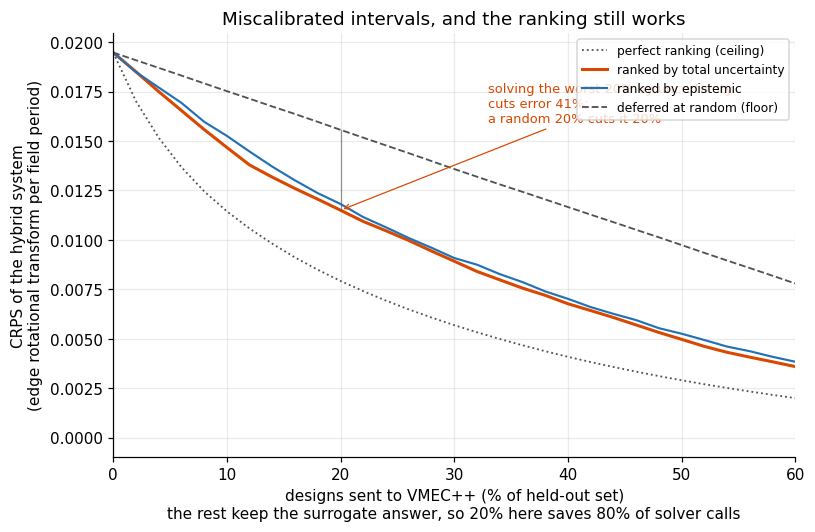

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

RANKINGS = {
    'oracle': ('perfect ranking (ceiling)', COLOR_NEUTRAL, ':', 1.2),
    'total': ('ranked by total uncertainty', COLOR_TAIL, '-', 2.0),
    'epistemic': ('ranked by epistemic', COLOR_HOLE, '-', 1.4),
    'random': ('deferred at random (floor)', COLOR_NEUTRAL, '--', 1.2),
}

out = deferral_curve[deferral_curve['region'] == 'out']

for name, (label, color, style, width) in RANKINGS.items():
    series = out[out['ranking'] == name].sort_values('deferred')
    ax.plot(
        series['deferred'] * 100,
        series['crps'],
        style,
        color=color,
        linewidth=width,
        label=label,
    )

# The single number the figure exists to deliver.
at_20 = {k: deferral['out']['rankings'][k]['crps_at']['0.2'] for k in RANKINGS}
none = deferral['out']['rankings']['total']['crps_at']['0']

ax.annotate(
    f'solving the worst 20% by uncertainty\ncuts error {1 - at_20["total"] / none:.0%};\n'
    f'a random 20% cuts it {1 - at_20["random"] / none:.0%}',
    xy=(20, at_20['total']),
    xytext=(33, none * 0.82),
    fontsize=8.5,
    color=COLOR_TAIL,
    arrowprops={'arrowstyle': '->', 'color': COLOR_TAIL, 'lw': 0.8},
)
ax.plot([20, 20], [at_20['total'], at_20['random']], color=COLOR_NEUTRAL, lw=0.8, alpha=0.6)

ax.set_xlim(0, 60)
ax.set_xlabel(
    'designs sent to VMEC++ (% of held-out set)\n'
    'the rest keep the surrogate answer, so 20% here saves 80% of solver calls'
)
ax.set_ylabel('CRPS of the hybrid system\n(edge rotational transform per field period)')
ax.set_title('Miscalibrated intervals, and the ranking still works')
ax.legend(fontsize=8)

keep(fig, 'deferral_curve')

## Figure 7: the decomposition earns its names

Step 8, the validation run. Everything above measures whether the uncertainty
is calibrated and whether it ranks. Both can be true while the split into two
terms is meaningless, because a signal that ranks well has said nothing about
which half of it is ignorance and which is noise.

The test is what the two names actually claim. **Epistemic is ignorance, so it
must shrink as data grows. Aleatoric is noise, so it must not.**

⚠️ On clean targets that second half has no content, because there the
aleatoric term is the model's own misfit and misfit does shrink with data. So
the sweep runs twice, once clean and once with Gaussian noise of a known
σ = 0.020 added to the training targets. The right panel subtracts the two in
quadrature, within seed, which pulls the injected component back out.

**The finding.** Left: epistemic falls monotonically in both conditions. Right:
the reducible part falls from 0.040 to 0.011 over a seventeenfold increase in
data, while the recovered injected part sits flat at 0.020, landing at 0.0208
against a true 0.020.

No exponent is fitted, per decision log 6.3. Five rungs at three seeds show a
shape and nothing finer.


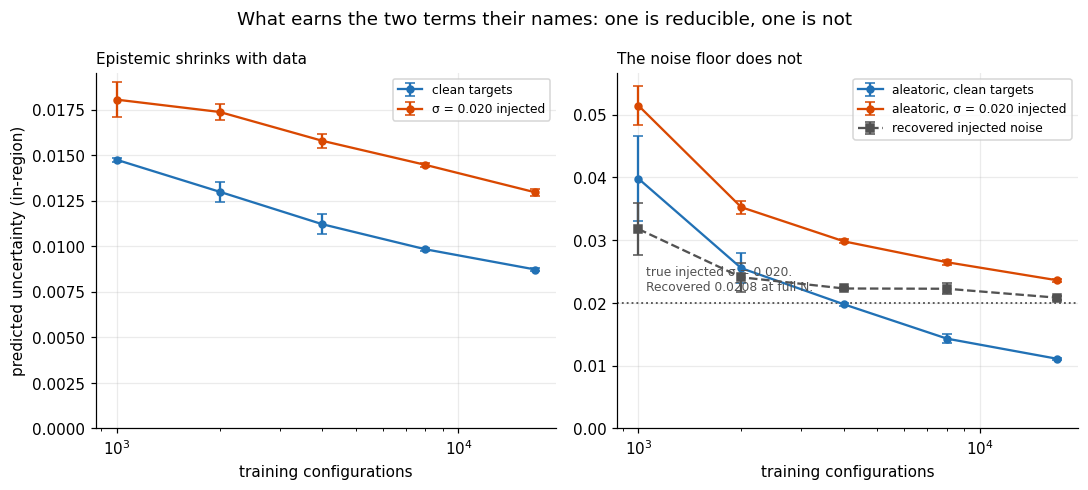

In [14]:
fig, (ax_epi, ax_ale) = plt.subplots(1, 2, figsize=(10, 4.5))

sizes = sorted({c['n_train'] for c in sweep_cells})
CONDITIONS = {0.0: ('clean targets', COLOR_HOLE), 0.02: ('σ = 0.020 injected', COLOR_TAIL)}


def cells_at(sigma, n):
    rows = [c for c in sweep_cells if c['sigma'] == sigma and c['n_train'] == n]
    return sorted(rows, key=lambda c: c['seed'])


def spread(sigma, n, term):
    values = [c['in_region'][term] for c in cells_at(sigma, n)]
    return np.mean(values), np.std(values)


for sigma, (label, color) in CONDITIONS.items():
    stats = [spread(sigma, n, 'epistemic') for n in sizes]
    ax_epi.errorbar(
        sizes,
        [m for m, _ in stats],
        yerr=[s for _, s in stats],
        fmt='o-',
        color=color,
        markersize=4.5,
        capsize=3,
        label=label,
    )

    stats = [spread(sigma, n, 'aleatoric') for n in sizes]
    ax_ale.errorbar(
        sizes,
        [m for m, _ in stats],
        yerr=[s for _, s in stats],
        fmt='o-',
        color=color,
        markersize=4.5,
        capsize=3,
        label=f'aleatoric, {label}',
    )

# Quadrature subtraction within seed: sqrt(noisy^2 - clean^2) recovers what was
# injected. This is the panel's actual claim, the two curves above are its inputs.
recovered = []
for n in sizes:
    pairs = zip(cells_at(0.0, n), cells_at(0.02, n), strict=True)
    per_seed = [
        np.sqrt(max(b['in_region']['aleatoric'] ** 2 - a['in_region']['aleatoric'] ** 2, 0.0))
        for a, b in pairs
    ]
    recovered.append((np.mean(per_seed), np.std(per_seed)))

ax_ale.errorbar(
    sizes,
    [m for m, _ in recovered],
    yerr=[s for _, s in recovered],
    fmt='s--',
    color=COLOR_NEUTRAL,
    markersize=5,
    capsize=3,
    label='recovered injected noise',
)
ax_ale.axhline(0.020, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.2)
ax_ale.annotate(
    f'true injected σ = 0.020.\nRecovered {recovered[-1][0]:.4f} at full N.',
    (sizes[0] * 1.05, 0.0215),
    fontsize=8,
    color=COLOR_NEUTRAL,
    va='bottom',
)

for ax, title in ((ax_epi, 'Epistemic shrinks with data'), (ax_ale, 'The noise floor does not')):
    ax.set_xscale('log')
    ax.set_xlabel('training configurations')
    ax.set_title(title, fontsize=10, loc='left')
    ax.legend(fontsize=8)

ax_epi.set_ylabel('predicted uncertainty (in-region)')
ax_epi.set_ylim(0, None)
ax_ale.set_ylim(0, None)
fig.suptitle('What earns the two terms their names: one is reducible, one is not')
fig.tight_layout()

keep(fig, 'n_sweep')

## Figure 8: more of the same data does not buy extrapolation

The N-sweep's second result, and the one with the most direct operational
meaning. Figure 7 asked whether the two uncertainty terms behave as their names
claim. This asks what happens to the extrapolation gap itself as the training
set grows.

Each point is the ratio of out-of-region to in-region RMSE, averaged over three
seeds, with the seed spread as error bars. It climbs from 1.71 to 3.39 as
training data grows seventeenfold. In-region error falls 67% across the sweep;
out-of-region falls only 29%.

⚠️ **State this narrowly or it overreaches.** Subsampling happens *within* the
training region, so "more data" here means more of the same distribution, and
more of a distribution cannot populate a region it excludes. The defensible
claim is that **scaling the existing dataset does not buy extrapolation
reliability**, so the answer is targeted sampling in the sparse region, or
deferral. That is also what the two 2026 compact-stellarator papers are doing.

⚠️ **A third claim was drafted and withdrawn before it reached this figure.**
"Out-of-region calibration degrades as N grows" came from reading seed 0 alone.
Across three seeds it is 0.85 ± 0.11 at N = 1,000 and then flat within noise:
0.62, 0.62, 0.65, 0.66. The whole apparent trend was the smallest rung, where
the model is poor everywhere and its uncertainty is honestly large. The correct
statement is that out-of-region calibration is stuck near 0.65 and more data
does not fix it, which supports deferral without pretending to a trend.


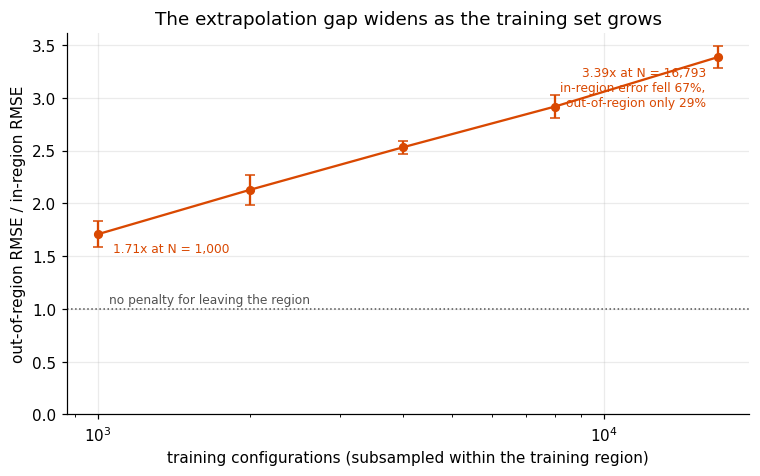

In [15]:
cells = load_results('n_sweep')['results']['cells']
clean = [c for c in cells if c['sigma'] == 0.0]
sizes = sorted({c['n_train'] for c in clean})


def gap_at(n):
    """Out-over-in RMSE for one rung, as (mean, spread) over seeds."""
    ratios = [c['out_region']['rmse'] / c['in_region']['rmse'] for c in clean if c['n_train'] == n]
    return np.mean(ratios), np.std(ratios)


stats = [gap_at(n) for n in sizes]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    sizes,
    [m for m, _ in stats],
    yerr=[s for _, s in stats],
    fmt='o-',
    color=COLOR_TAIL,
    markersize=5,
    capsize=3,
)

# 1.0 is where holding out the compact end costs nothing. The curve moving away
# from it is the finding.
ax.axhline(1.0, color=COLOR_NEUTRAL, linestyle=':', linewidth=1)
ax.annotate(
    'no penalty for leaving the region',
    (sizes[0] * 1.05, 1.03),
    fontsize=8,
    color=COLOR_NEUTRAL,
    va='bottom',
)

first, last = stats[0][0], stats[-1][0]
ax.annotate(
    f'{first:.2f}x at N = {sizes[0]:,}',
    (sizes[0], first),
    textcoords='offset points',
    xytext=(10, -12),
    fontsize=8,
    color=COLOR_TAIL,
)
ax.annotate(
    f'{last:.2f}x at N = {sizes[-1]:,}\nin-region error fell 67%,\nout-of-region only 29%',
    (sizes[-1], last),
    textcoords='offset points',
    xytext=(-8, -6),
    ha='right',
    va='top',
    fontsize=8,
    color=COLOR_TAIL,
)

ax.set_xscale('log')
ax.set_ylim(0, None)
ax.set_xlabel('training configurations (subsampled within the training region)')
ax.set_ylabel('out-of-region RMSE / in-region RMSE')
ax.set_title('The extrapolation gap widens as the training set grows')

keep(fig, 'gap_vs_n')

# Supporting evidence

Everything above is a deliverable. What follows is the evidence from the
earlier gates, kept because each one answers an obvious objection to the
results above rather than because it stands on its own.

Reads `results/*.json`, so it needs those scripts to have been run. Fast.


In [16]:
grid = load_results('day_1_2_grid')['results']
noise = load_results('stage_2_noise_floor')['results']
gate = load_results('gate_3_5_split_axis')['results']

print('grid rows:', len(grid['rows']))
print('noise floor targets:', list(noise['residual_spread']))
print('gate verdict:', gate['verdict'])

grid rows: 12
noise floor targets: ['edge_rot_transform', 'log10_qi']
gate verdict: INCONCLUSIVE


## Figure 9: generalization gap by axis and cut

The day 1-2 result in one picture. The reference line at 1.0 is where holding
data out costs nothing.

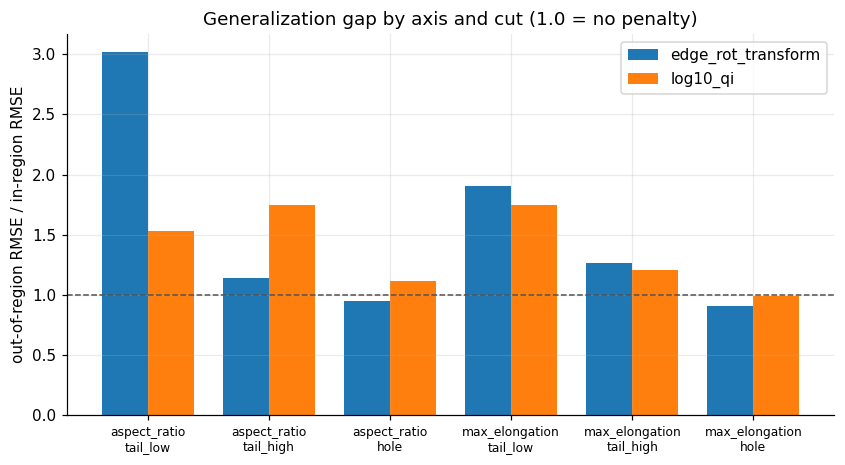

In [17]:
rows = grid['rows']
targets = sorted({r['target'] for r in rows})

combos = []
for r in rows:
    if (r['axis'], r['cut']) not in combos:
        combos.append((r['axis'], r['cut']))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(combos))
width = 0.38

for i, target in enumerate(targets):
    values = [
        next(r['ratio'] for r in rows if (r['axis'], r['cut']) == c and r['target'] == target)
        for c in combos
    ]
    ax.bar(x + (i - 0.5) * width, values, width, label=target)

ax.axhline(1.0, color=COLOR_NEUTRAL, linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([f'{a}\n{c}' for a, c in combos], fontsize=8)
ax.set_ylabel('out-of-region RMSE / in-region RMSE')
ax.set_title('Generalization gap by axis and cut (1.0 = no penalty)')
ax.legend()

keep(fig, 'grid_ratios')

## Figure 10: the noise floor

The dashed line is fitted to the three closest bins and extended back to zero
distance. Its intercept is the floor estimate, which is the point of the figure.

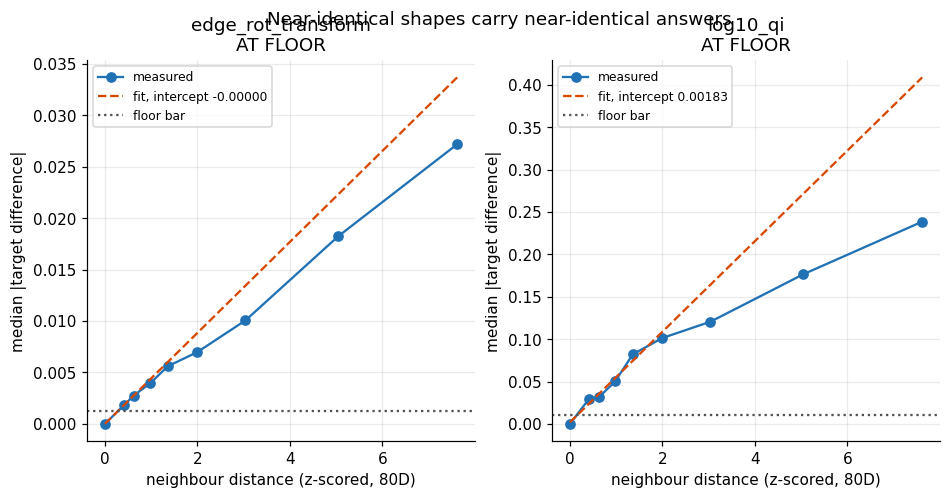

In [18]:
spread = noise['residual_spread']

fig, axes = plt.subplots(1, len(spread), figsize=(10, 4.5))
axes = np.atleast_1d(axes)

for ax, (name, result) in zip(axes, spread.items(), strict=False):
    d = [b['median_distance'] for b in result['bins']]
    gap = [b['median_delta'] for b in result['bins']]

    ax.plot(d, gap, 'o-', color=COLOR_HOLE, label='measured')

    xs = np.linspace(0, max(d), 50)
    ax.plot(
        xs,
        result['intercept'] + result['slope'] * xs,
        '--',
        color=COLOR_TAIL,
        label=f'fit, intercept {result["intercept"]:.5f}',
    )
    ax.axhline(result['bar'], color=COLOR_NEUTRAL, linestyle=':', label='floor bar')

    ax.set_xlabel('neighbour distance (z-scored, 80D)')
    ax.set_ylabel('median |target difference|')
    ax.set_title(f'{name}\n{result["verdict"]}')
    ax.legend(fontsize=8)

fig.suptitle('Near-identical shapes carry near-identical answers')

keep(fig, 'noise_floor')

## Figure 11: error tracks data density

From gate 3.5. Supporting evidence, and notable because it shows the
extrapolation premise in a purely geometric quantity, before any surrogate
exists.

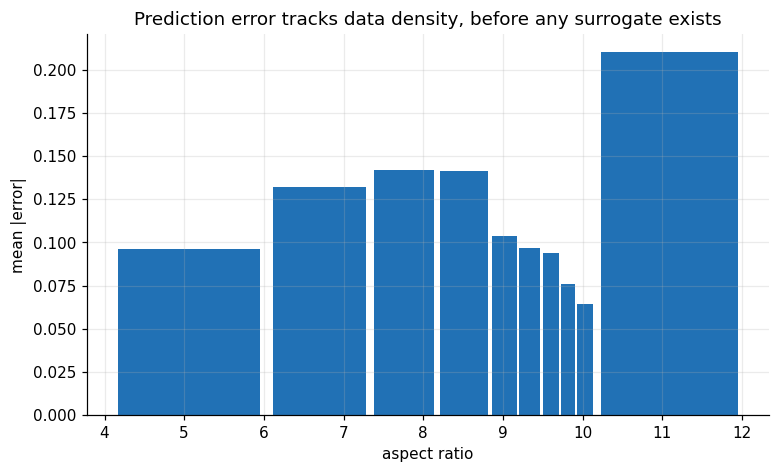

In [19]:
deciles = gate['deciles']

centres = [(d['lo'] + d['hi']) / 2 for d in deciles]
errors = [d['mean_abs_error'] for d in deciles]
widths = [(d['hi'] - d['lo']) * 0.9 for d in deciles]

fig, ax = plt.subplots()
ax.bar(centres, errors, width=widths, color=COLOR_HOLE)

ax.set_xlabel('aspect ratio')
ax.set_ylabel('mean |error|')
ax.set_title('Prediction error tracks data density, before any surrogate exists')

keep(fig, 'gate_3_5_deciles')

## Save

Writes everything stashed in `FIGS` to `figures/` as PNG and PDF. Only the
figures whose cells you have run are present, so re-run a cell before saving if
you changed it.

In [20]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for name, fig in FIGS.items():
    for suffix in ('png', 'pdf'):
        fig.savefig(FIGURES_DIR / f'{name}.{suffix}')
    print(f'wrote figures/{name}.png and .pdf')

wrote figures/split_design.png and .pdf
wrote figures/distance_error.png and .pdf
wrote figures/coverage_distance.png and .pdf
wrote figures/coverage_nominal.png and .pdf
wrote figures/pit_histograms.png and .pdf
wrote figures/deferral_curve.png and .pdf
wrote figures/n_sweep.png and .pdf
wrote figures/gap_vs_n.png and .pdf
wrote figures/grid_ratios.png and .pdf
wrote figures/noise_floor.png and .pdf
wrote figures/gate_3_5_deciles.png and .pdf


## Scratch

Prototype new figures here. When one settles, give it a `keep(fig, 'name')` and
add it to the port list for `scripts/make_figures.py`.